# Reaction-Diffusion POD-Galerkin DEIM stability check

The state is the pair of scalar fields `[v1; v2]`. The reference reactions are `s1(v1,v2) = v1 - v1^3 - v2 - 0.005` and `s2(v1,v2) = 10(v1-v2)`. The difference `v1-v2` is plotted only as an optional diagnostic.

In [1]:
repo_root = normpath(joinpath(@__DIR__, "..", ".."))
include(joinpath(repo_root, "src", "HPC", "Simulations", "FOM_opt_RD_hpc.jl"))
include(joinpath(repo_root, "src", "HPC", "Simulations", "ROM_opt_RD_hpc.jl"))
include(joinpath(repo_root, "src", "HPC", "Tools", "Sweeps", "RD_initial_conditions.jl"))
using Plots
default(size=(900, 380), colorbar=true)

[package-load] Loading LinearAlgebra
[package-load] Loaded LinearAlgebra
[package-load] Loading SparseArrays
[package-load] Loaded SparseArrays
[package-load] Loading Random
[package-load] Loaded Random
[package-load] Loading ComponentArrays
[package-load] Loaded ComponentArrays
[package-load] Loading OrdinaryDiffEq
[package-load] Loaded OrdinaryDiffEq
[package-load] Loading OrdinaryDiffEqSDIRK
[package-load] Loaded OrdinaryDiffEqSDIRK
[package-load] Loading SciMLSensitivity
[package-load] Loaded SciMLSensitivity
[package-load] Loading ADTypes
[package-load] Loaded ADTypes
[package-load] Loading Zygote
[package-load] Loaded Zygote
[package-load] Loading Mooncake
[package-load] Loaded Mooncake
[package-load] Loading Optimization
[package-load] Loaded Optimization
[package-load] Loading OptimizationOptimisers
[package-load] Loaded OptimizationOptimisers
[package-load] Loading Lux
[package-load] Loaded Lux
[package-load] Loading Functors
[package-load] Loaded Functors
[package-load] Loadi

In [ ]:
N = 32
L = 1.0
D1 = 2.8e-4
D2 = 5.0e-2
tfinal = 32.0
u₀ = rd_materialize_sweep_initial_condition("random"; N, L, dimension=2, boundary_condition="neumann", seed=1)
reference = build_rd_reference(; N, L, D1, D2, tfinal, reference_dt_factor=0.1, dimension=2, boundary_condition="neumann", u₀)
reference_reactions = (s1="v1-v1^3-v2-0.005", s2="10*(v1-v2)")
println(reference_reactions)
@assert maximum(abs, reference.lap * ones(N^2)) < 1e-12

[build_rd_reference] [2026-07-14 01:41:45] Reference solve: N=32, Δx=0.03225806451612903, saved_times=500, dimension=2
(s1 = "v1-v1^3-v2-0.005", s2 = "10*(v1-v2)")


In [3]:
r = 12
m = 12
rom_prob = build_RD_ROM_reference(reference, r, m)
rom_solution = solve(rom_prob, TRBDF2(autodiff=AutoFiniteDiff()); saveat=reference.t)
fom_frames = reference.u_ref.u
rom_frames = [rom_prob.f.f.data.rom.Phi * a for a in rom_solution.u]
println("FOM snapshots = ", length(fom_frames), ", ROM snapshots = ", length(rom_frames), ", DEIM points = ", length(rom_prob.f.f.data.rom.points))

FOM snapshots = 500, ROM snapshots = 500, DEIM points = 12


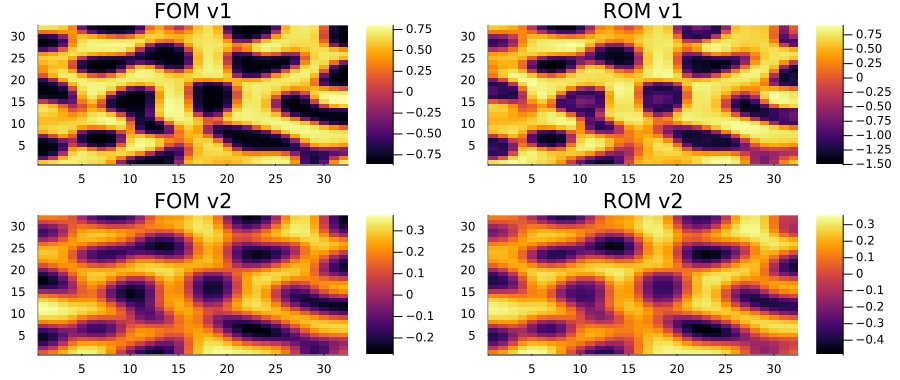

In [4]:
k = length(reference.t)
v1_fom = reshape(fom_frames[k][1:N^2], N, N)
v2_fom = reshape(fom_frames[k][N^2+1:2N^2], N, N)
v1_rom = reshape(rom_frames[k][1:N^2], N, N)
v2_rom = reshape(rom_frames[k][N^2+1:2N^2], N, N)
plot(heatmap(v1_fom, title="FOM v1"), heatmap(v1_rom, title="ROM v1"), heatmap(v2_fom, title="FOM v2"), heatmap(v2_rom, title="ROM v2"), layout=(2,2))

In [5]:
# plot(heatmap(v1_fom .- v2_fom, title="Optional diagnostic: FOM v1-v2"), heatmap(v1_rom .- v2_rom, title="Optional diagnostic: ROM v1-v2"), layout=(1,2))

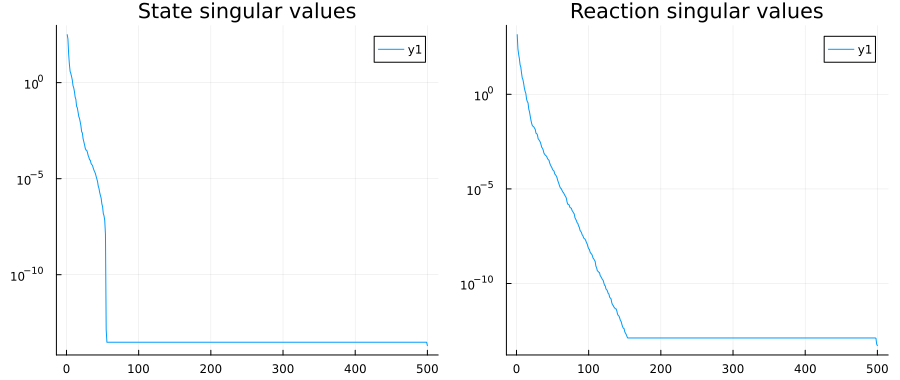

In [6]:
state_singular_values = rom_prob.f.f.data.rom.state_singular_values
nonlinear_singular_values = rom_prob.f.f.data.rom.nonlinear_singular_values
plot(plot(state_singular_values, yscale=:log10, title="State singular values"), plot(nonlinear_singular_values, yscale=:log10, title="Reaction singular values"), layout=(1,2))

┌ Info: Saved animation to /var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_FCfAZ4FiXw.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_FCfAZ4FiXw.gif")
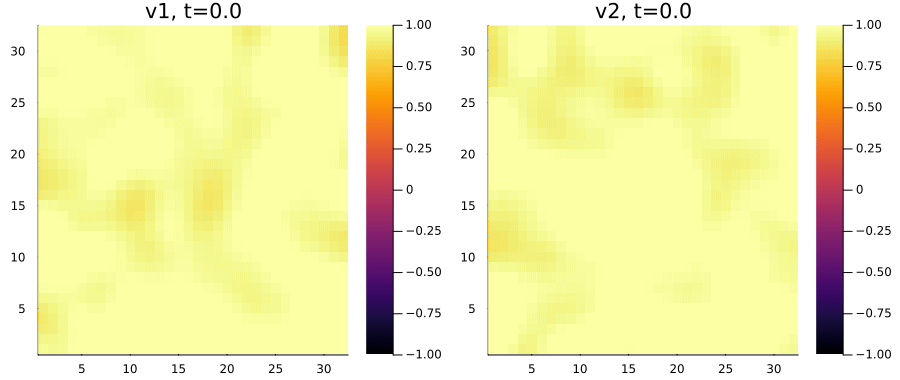

In [7]:
N2 = N^2

v1_min = -1.0 #minimum(minimum(frame[1:N2]) for frame in fom_frames)
v1_max = 1.0 #maximum(maximum(frame[1:N2]) for frame in fom_frames)

v2_min = -1.0 #minimum(minimum(frame[N2+1:2N2]) for frame in fom_frames)
v2_max = 1.0 #maximum(maximum(frame[N2+1:2N2]) for frame in fom_frames)

@gif for j in eachindex(reference.t)
    v1 = reshape(fom_frames[j][1:N2], N, N)
    v2 = reshape(fom_frames[j][N2+1:2N2], N, N)

    p1 = heatmap(
        v1;
        title="v1, t=$(round(reference.t[j]; digits=3))",
        clims=(v1_min, v1_max),
        colorbar=true,
    )

    p2 = heatmap(
        v2;
        title="v2, t=$(round(reference.t[j]; digits=3))",
        clims=(v2_min, v2_max),
        colorbar=true,
    )

    plot(p1, p2; layout=(1, 2))
end every max(1, cld(length(reference.t), 20))